<div align="center">

# 🎗️ Naïve Bayes Classification Using the 20 Newsgroups Dataset

### 20 Newsgroups Text Classification Dataset

*Implementation and Performance Comparison of Multinomial Naïve Bayes & Bernoulli Naïve Bayes for Text Classification*

</div>


## 📚 1. Import Required Libraries

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

## 📥 2. Loading the 20 Newsgroups Training Dataset

---

In [3]:
train_data = fetch_20newsgroups(
    subset = "train",
    remove=("headers", "footers", "quotes")
)

## 📤 3. Loading the 20 Newsgroups Test Dataset

---

In [4]:
test_data = fetch_20newsgroups(
    subset="test",
    remove=("headers", "footers", "quotes")
)

## 📊 4. Preparing Training and Testing Data

---

In [5]:
X_train_text = train_data.data
y_train = train_data.target

X_test_text = test_data.data
y_test = test_data.target

class_names = train_data.target_names

## 📊 5. Dataset Statistics

---

In [6]:
print("Training documents :", len(X_train_text))
print("Testing documents :", len(X_test_text))
print("Number of classes :", len(class_names))

Training documents : 11314
Testing documents : 7532
Number of classes : 20


## 🔤 6. Text Vectorization and Feature Matrix

---

In [9]:
vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2
)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)
print("Training feature matrix:", X_train.shape)
print("Testing feature matrix:", X_test.shape)

Training feature matrix: (11314, 39115)
Testing feature matrix: (7532, 39115)


## 🤖 7. Implement Multinomial Naïve Bayes Classifier

---

In [10]:
mnb = MultinomialNB()
mnb.fit(
    X_train,
    y_train
)

y_pred_mnb = mnb.predict(X_test)

## 🔢 8. Convert Text into Binary Feature Representation

---

In [14]:
binary_vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2,
    binary=True
)
X_train_binary = binary_vectorizer.fit_transform(
    X_train_text
)
X_test_binary = binary_vectorizer.transform(
    X_test_text
)

## 🤖 9. Implement Bernoulli Naïve Bayes Classifier

---

In [15]:
bnb = BernoulliNB()

bnb.fit(
    X_train_binary,
    y_train
)

y_pred_bnb = bnb.predict(
    X_test_binary
)

## 📊 10. Evaluate the Performance of Both Naïve Bayes Models

---

In [21]:
mnb_accuracy = accuracy_score(y_test, y_pred_mnb)
mnb_precision = precision_score(y_test, y_pred_mnb, average="weighted")
mnb_recall = recall_score(y_test, y_pred_mnb, average="weighted")
mnb_f1 = f1_score(y_test, y_pred_mnb, average="weighted")

bnb_accuracy = accuracy_score(y_test, y_pred_bnb)
bnb_precision = precision_score(y_test, y_pred_bnb, average="weighted")
bnb_recall = recall_score(y_test, y_pred_bnb, average="weighted")
bnb_f1 = f1_score(y_test, y_pred_bnb, average="weighted")

In [22]:
print("Multinomial Naïve Bayes")
print("-----------------------")
print("Accuracy  :", mnb_accuracy)
print("Precision :", mnb_precision)
print("Recall    :", mnb_recall)
print("F1-Score  :", mnb_f1)

print("\nBernoulli Naïve Bayes")
print("--------------------")
print("Accuracy  :", bnb_accuracy)
print("Precision :", bnb_precision)
print("Recall    :", bnb_recall)
print("F1-Score  :", bnb_f1)

Multinomial Naïve Bayes
-----------------------
Accuracy  : 0.6510886882634095
Precision : 0.642532222238185
Recall    : 0.6510886882634095
F1-Score  : 0.6296441343359875

Bernoulli Naïve Bayes
--------------------
Accuracy  : 0.4851301115241636
Precision : 0.6270343160004399
Recall    : 0.4851301115241636
F1-Score  : 0.4808387927958853


## 📋 11. Create a Performance Comparison Table

---

In [23]:
results = pd.DataFrame({
    "Model": [
        "Multinomial Naïve Bayes",
        "Bernoulli Naïve Bayes"
    ],
    "Accuracy": [
        mnb_accuracy,
        bnb_accuracy
    ],
    "Precision": [
        mnb_precision,
        bnb_precision
    ],
    "Recall": [
        mnb_recall,
        bnb_recall
    ],
    "F1-Score": [
        mnb_f1,
        bnb_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naïve Bayes,0.651089,0.642532,0.651089,0.629644
1,Bernoulli Naïve Bayes,0.485130,0.627034,0.485130,0.480839


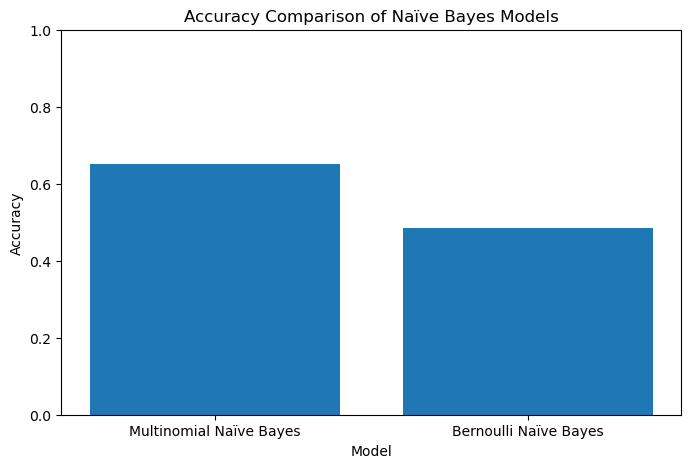

In [24]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Naïve Bayes Models")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()

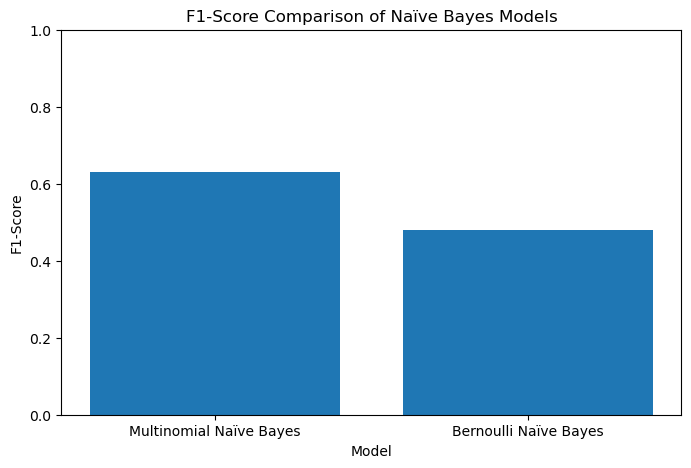

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["F1-Score"]
)

plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.title("F1-Score Comparison of Naïve Bayes Models")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()

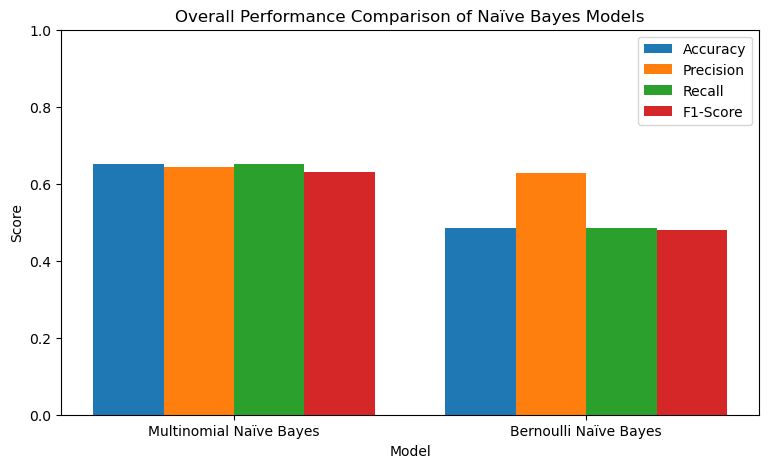

In [26]:
plt.figure(figsize=(9, 5))

x = np.arange(len(results["Model"]))
width = 0.2

plt.bar(
    x - 1.5 * width,
    results["Accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x - 0.5 * width,
    results["Precision"],
    width,
    label="Precision"
)

plt.bar(
    x + 0.5 * width,
    results["Recall"],
    width,
    label="Recall"
)

plt.bar(
    x + 1.5 * width,
    results["F1-Score"],
    width,
    label="F1-Score"
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Overall Performance Comparison of Naïve Bayes Models")
plt.xticks(x, results["Model"])
plt.ylim(0, 1)
plt.legend()

plt.show()

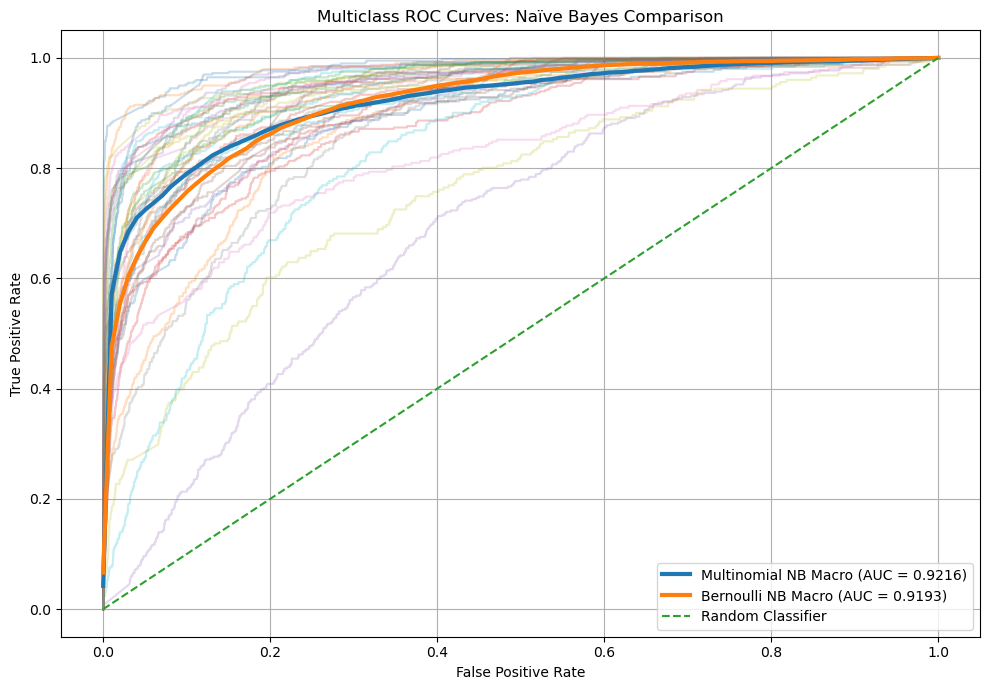

Multinomial Naïve Bayes Macro-Average AUC: 0.9215566790809501
Bernoulli Naïve Bayes Macro-Average AUC: 0.9193156969856776


In [29]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score, auc
import matplotlib.pyplot as plt
import numpy as np

y_score_mnb = mnb.predict_proba(X_test)
y_score_bnb = bnb.predict_proba(X_test)

y_test_bin = label_binarize(y_test, classes=mnb.classes_)

auc_mnb = roc_auc_score(
    y_test_bin,
    y_score_mnb,
    average="macro",
    multi_class="ovr"
)

auc_bnb = roc_auc_score(
    y_test_bin,
    y_score_bnb,
    average="macro",
    multi_class="ovr"
)

plt.figure(figsize=(10, 7))

for i in range(y_test_bin.shape[1]):
    fpr_mnb, tpr_mnb, _ = roc_curve(
        y_test_bin[:, i],
        y_score_mnb[:, i]
    )

    fpr_bnb, tpr_bnb, _ = roc_curve(
        y_test_bin[:, i],
        y_score_bnb[:, i]
    )

    plt.plot(
        fpr_mnb,
        tpr_mnb,
        alpha=0.25
    )

    plt.plot(
        fpr_bnb,
        tpr_bnb,
        alpha=0.25
    )

mean_fpr = np.linspace(0, 1, 100)

tprs_mnb = []
tprs_bnb = []

for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score_mnb[:, i]
    )
    tprs_mnb.append(
        np.interp(mean_fpr, fpr, tpr)
    )

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score_bnb[:, i]
    )
    tprs_bnb.append(
        np.interp(mean_fpr, fpr, tpr)
    )

mean_tpr_mnb = np.mean(tprs_mnb, axis=0)
mean_tpr_bnb = np.mean(tprs_bnb, axis=0)

plt.plot(
    mean_fpr,
    mean_tpr_mnb,
    linewidth=3,
    label=f"Multinomial NB Macro (AUC = {auc_mnb:.4f})"
)

plt.plot(
    mean_fpr,
    mean_tpr_bnb,
    linewidth=3,
    label=f"Bernoulli NB Macro (AUC = {auc_bnb:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves: Naïve Bayes Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Multinomial Naïve Bayes Macro-Average AUC:", auc_mnb)
print("Bernoulli Naïve Bayes Macro-Average AUC:", auc_bnb)